# Modeling

---


## Pendekatan

| Aspek | Keputusan |
|-------|-----------|
| Tuning | GridSearchCV (CV=5) untuk semua model |
| Metrik utama | **F1 Macro** dimana lebih adil untuk multiclass (Low/Medium/High) |
| Evaluasi akhir | Held out test set yang sama untuk semua model |
| Deteksi overfit | Learning curve dengan train vs validation F1 across training sizes |

**Model yang diuji:** Logistic Regression, SVM, Random Forest, Naive Bayes, KNN

 Kami menggunakan gridsearcg agar perbandingan benar-benar adil dimana semua model sudah di tune dengan parameter terbaik maing-masing sebelum dibandingkan.

## 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style='whitegrid')

## 2. Load Dataset

Load hasil preprocessing. Kolom `burnout_encoded` adalah target (0=Low, 1=Medium, 2=High), sisanya adalah fitur.

In [3]:
df = pd.read_csv('dataset_preprocessed.csv')
print(f'Shape: {df.shape}')
print(f'Fitur: {[c for c in df.columns if c != "burnout_encoded"]}')
print(f'Target: {dict(df["burnout_encoded"].value_counts().sort_index())}')
df.head()

Shape: (7000, 11)
Fitur: ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours']
Target: {0: np.int64(1593), 1: np.int64(3625), 2: np.int64(1782)}


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,burnout_encoded
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,1
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,2
2,34.0,13.0,8.99,4.03,5.0,2.0,18.0,9.0,11.18,1.54,1
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,1
4,27.0,7.0,4.24,5.80,4.0,9.0,17.0,7.0,8.05,0.36,0


## 3. Train dan Test Split

Split 80% training dan 20% testing dengan `stratify=y` agar proporsi kelas Low/Medium/High tetap seimbang di kedua set.

In [4]:
X = df.drop(columns=['burnout_encoded'])
y = df['burnout_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} baris ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} baris ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'\nDistribusi kelas di train:')
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1).to_string())
print(f'\nDistribusi kelas di test:')
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

Train: 5600 baris (80.0%)
Test: 1400 baris (20.0%)

Distribusi kelas di train:
burnout_encoded
0    22.8
1    51.8
2    25.5

Distribusi kelas di test:
burnout_encoded
0    22.8
1    51.8
2    25.4


## 4. Helper Functions

Dua fungsi utama yang dipakai di seluruh notebook:

- **`plot_learning_curve()`** ini untuk memplot Train vs Validation F1 Macro terhadap ukuran training set. Digunakan untuk mendeteksi overfittin dan underfitting.
- **`run_model()`** function GridSearchCV untuk mencari best params lalu membuat confusion matrix dan learning curve lalu simpan hasil ke `results`.

In [5]:
results = {}
LABEL_NAMES = ['Low', 'Medium', 'High']


def plot_learning_curve(name, estimator, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        clone(estimator), X, y,
        cv=5, scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1, shuffle=True, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.1:
        diagnosis = f'Overfit gap = {gap:.3f} (> 0.10)'
    elif val_mean[-1] < 0.50:
        diagnosis = f'Underfit val F1 = {val_mean[-1]:.3f} (< 0.50)'
    else:
        diagnosis = f'Good fit gap = {gap:.3f}'

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', lw=2, label='Train F1 Macro')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#2ecc71')
    ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', lw=2, label='Validation F1 Macro')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#e74c3c')
    ax.set_title(f'Learning Curve {name}\n{diagnosis}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Training Size')
    ax.set_ylabel('F1 Macro')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def run_model(name, estimator, param_grid):

    print(f"  {name}")

    gs = GridSearchCV(
        estimator, param_grid,
        cv=5, scoring='f1_macro',
        n_jobs=-1, verbose=0
    )
    gs.fit(X_train, y_train)

    best  = gs.best_estimator_
    cv_f1 = gs.best_score_
    print(f"Best params: {gs.best_params_}")
    print(f"CV F1 Macro: {cv_f1:.4f}")

    y_pred   = best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average='macro')
    print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"Test F1 Macro : {test_f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    plot_learning_curve(name, best, X_train, y_train)

    results[name] = {
        'CV F1 Macro'  : round(cv_f1, 4),
        'Test F1 Macro': round(test_f1, 4),
        'Test Accuracy': round(test_acc, 4),
        'Best Params'  : gs.best_params_,
        'estimator'    : best
    }
    return best

## 5. Logistic Regression

Model linear yang mempelajari batas keputusan linier antar kelas. `C` adalah parameter regularisasi dimana semakin kecil nilainya, semakin kuat regularisasi (mengurangi variance/overfit). Butuh **StandardScaler** karena sensitif terhadap skala fitur.

`Pipeline` memastikan scaler hanya `fit` di training fold saat GridSearchCV, mencegah **data leakage**.

  Logistic Regression


c:\Users\LENOVO\anaconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'model__C': 1}
CV F1 Macro: 0.7770
Test Accuracy : 0.7921 (79.21%)
Test F1 Macro : 0.7855
              precision    recall  f1-score   support

         Low       0.82      0.73      0.77       319
      Medium       0.78      0.84      0.81       725
        High       0.80      0.75      0.78       356

    accuracy                           0.79      1400
   macro avg       0.80      0.77      0.79      1400
weighted avg       0.79      0.79      0.79      1400



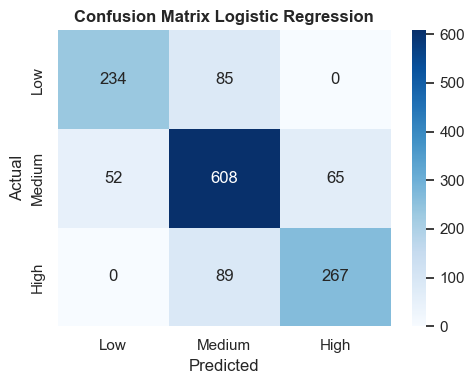

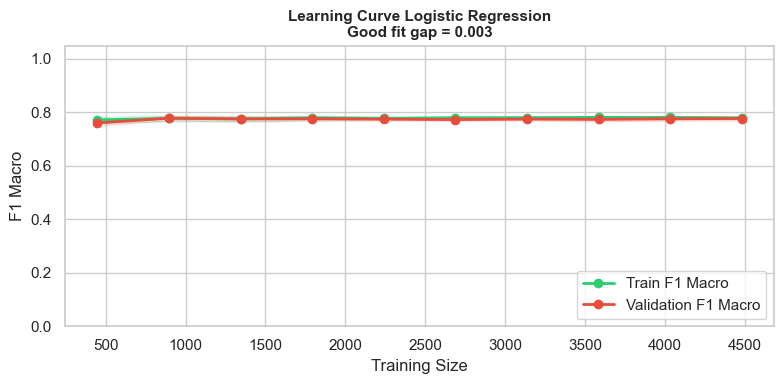

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1


In [6]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42,
                                  multi_class='multinomial', solver='lbfgs'))
])

lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

run_model('Logistic Regression', lr_pipe, lr_param_grid)

## 6. Support Vector Machine (SVM)

SVM mencari **hyperplane** yang memaksimalkan margin antar kelas. Kernel RBF memetakan data ke dimensi lebih tinggi sehingga bisa menangani batas keputusan non-linear. Parameter kunci: `C` (regularisasi) dan `gamma` (lebar kernel). Butuh scaling karena berbasis jarak.

  SVM
Best params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
CV F1 Macro: 0.7649
Test Accuracy : 0.7807 (78.07%)
Test F1 Macro : 0.7728
              precision    recall  f1-score   support

         Low       0.80      0.71      0.75       319
      Medium       0.76      0.83      0.80       725
        High       0.80      0.74      0.77       356

    accuracy                           0.78      1400
   macro avg       0.79      0.76      0.77      1400
weighted avg       0.78      0.78      0.78      1400



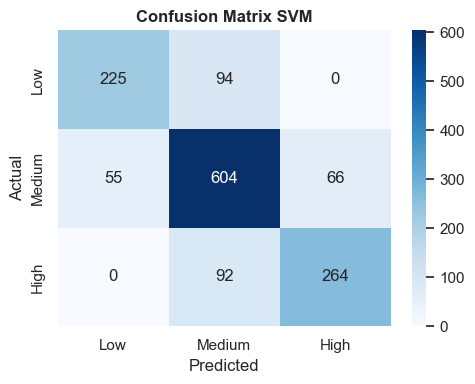

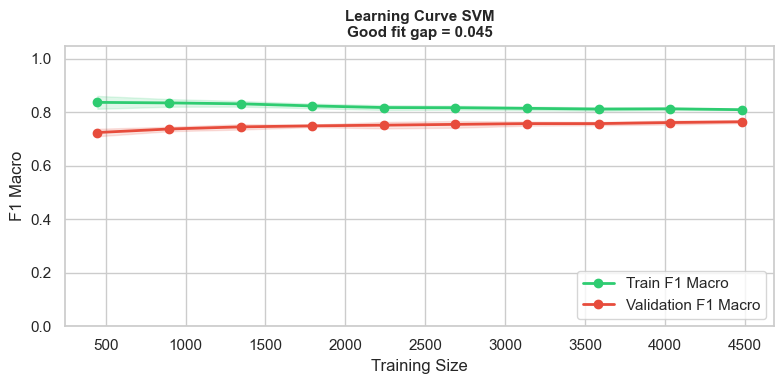

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [17]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42, probability=True))
])

svm_param_grid = {
    'model__C'     : [0.1, 1, 10, 100],
    'model__gamma' : ['scale', 'auto'],
    'model__kernel': ['rbf', 'poly']
}

run_model('SVM', svm_pipe, svm_param_grid)

## 7. Random Forest

Ensemble dari banyak Decision Tree yang ditrain secara paralel dengan teknik **bagging** (bootstrap aggregating). Setiap tree dilatih pada subset data dan fitur yang berbeda, lalu hasil prediksi divoting. Tidak butuh scaling karena pemisahan berbasis threshold, bukan jarak.

  Random Forest
Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
CV F1 Macro: 0.7416
Test Accuracy : 0.7650 (76.50%)
Test F1 Macro : 0.7533
              precision    recall  f1-score   support

         Low       0.81      0.66      0.73       319
      Medium       0.74      0.84      0.79       725
        High       0.79      0.70      0.74       356

    accuracy                           0.77      1400
   macro avg       0.78      0.73      0.75      1400
weighted avg       0.77      0.77      0.76      1400



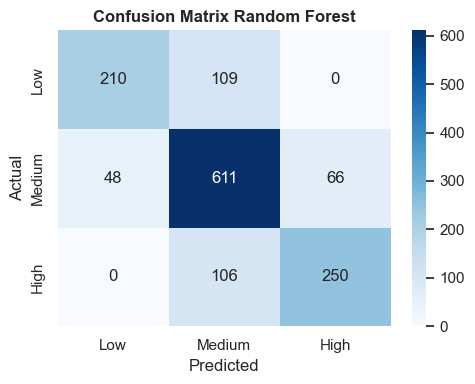

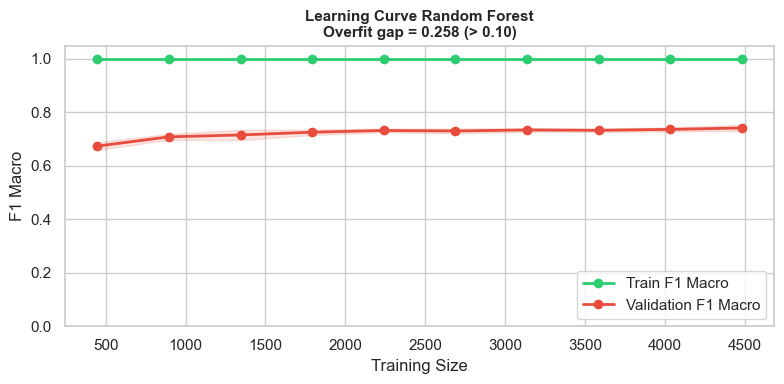

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, 15,20],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2']
}

run_model('Random Forest',
          RandomForestClassifier(random_state=42, n_jobs=-1),
          rf_param_grid)

## 8. Naive Bayes (Gaussian)

Model probabilistik berbasis Teorema Bayes dengan asumsi tiap fitur **independen** satu sama lain (*naive*). Gaussian NB mengasumsikan distribusi normal untuk setiap fitur. Parameter `var_smoothing` menambahkan sedikit noise untuk stabilitas numerik.

  Naive Bayes
Best params: {'var_smoothing': 1e-09}
CV F1 Macro: 0.7241
Test Accuracy : 0.7507 (75.07%)
Test F1 Macro : 0.7444
              precision    recall  f1-score   support

         Low       0.79      0.70      0.74       319
      Medium       0.74      0.79      0.77       725
        High       0.73      0.71      0.72       356

    accuracy                           0.75      1400
   macro avg       0.76      0.74      0.74      1400
weighted avg       0.75      0.75      0.75      1400



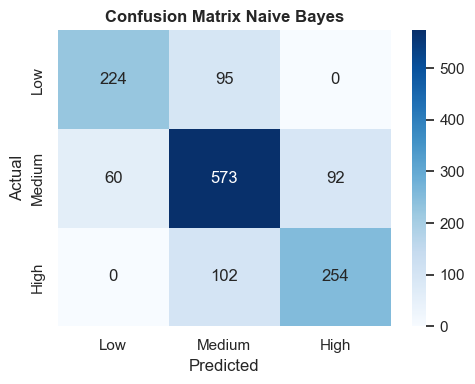

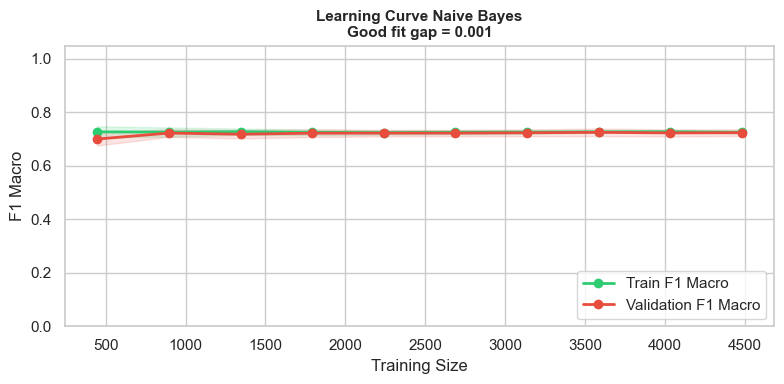

,priors,None
,var_smoothing,1e-09


In [9]:
nb_param_grid = {
    'var_smoothing': [1e-9, 1e-7, 1e-5, 1e-3, 1e-1]
}

run_model('Naive Bayes', GaussianNB(), nb_param_grid)

## 9. K-Nearest Neighbors (KNN)

KNN memprediksi kelas berdasarkan mayoritas kelas dari **KNN** di ruang fitur. Tidak ada "training" eksplisit dimana model hanya mengingat seluruh data training. Sangat sensitif terhadap skala, sehingga wajib pakai StandardScaler.

  KNN
Best params: {'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'uniform'}
CV F1 Macro: 0.7168
Test Accuracy : 0.7457 (74.57%)
Test F1 Macro : 0.7299
              precision    recall  f1-score   support

         Low       0.75      0.62      0.68       319
      Medium       0.72      0.84      0.77       725
        High       0.82      0.67      0.74       356

    accuracy                           0.75      1400
   macro avg       0.76      0.71      0.73      1400
weighted avg       0.75      0.75      0.74      1400



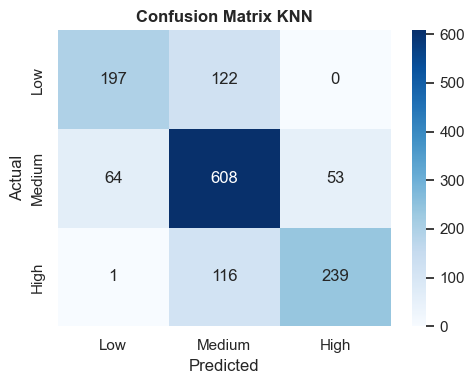

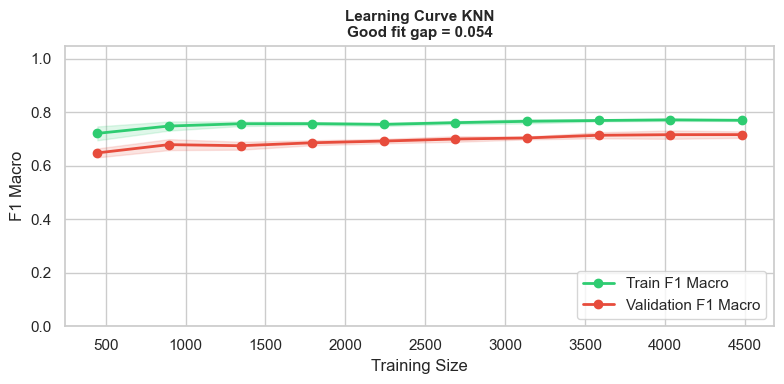

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [10]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights'    : ['uniform', 'distance'],
    'model__metric'     : ['euclidean', 'manhattan']
}

run_model('KNN', knn_pipe, knn_param_grid)

## 10. Perbandingan Final

Semua model dibandingkan pada kondisi yang **sama dan adil**:
- Semua sudah di-tune dengan GridSearchCV (CV=5)
- Metrik utama: **CV F1 Macro** performa rata-rata di training folds, lebih robust
- Metrik pendukung: **Test F1 Macro** performa di held-out test set yang belum pernah dilihat
- **Gap = CV − Test F1**: gap besar (> 0.05) mengindikasikan model overfit ke training folds

              Model  CV F1 Macro  Test F1 Macro  Test Accuracy  Gap (CV-Test)
Logistic Regression       0.7770         0.7855         0.7921        -0.0085
                SVM       0.7649         0.7728         0.7807        -0.0079
      Random Forest       0.7459         0.7533         0.7650        -0.0074
        Naive Bayes       0.7241         0.7444         0.7507        -0.0203
                KNN       0.7168         0.7299         0.7457        -0.0131


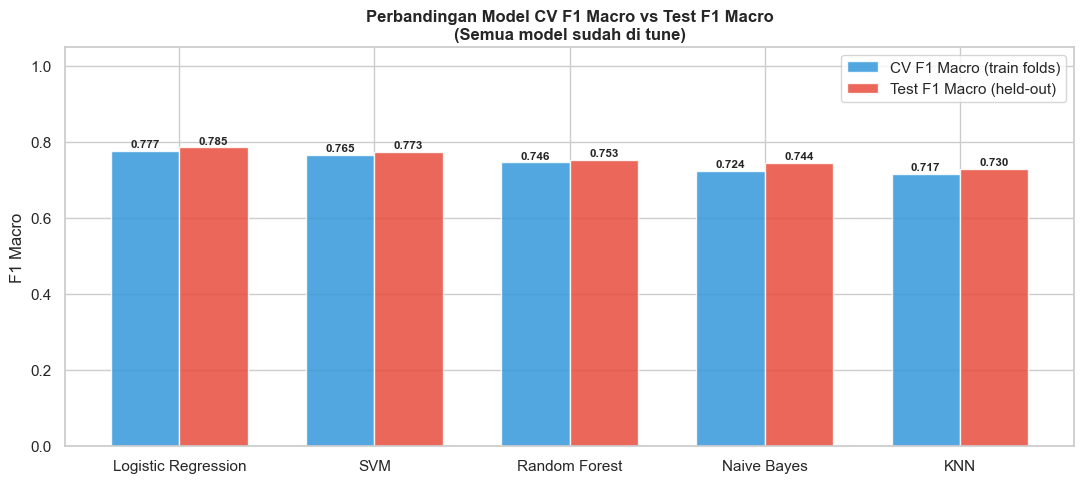

In [11]:
comp = pd.DataFrame([
    {
        'Model'        : k,
        'CV F1 Macro'  : v['CV F1 Macro'],
        'Test F1 Macro': v['Test F1 Macro'],
        'Test Accuracy': v['Test Accuracy'],
        'Gap (CV-Test)': round(v['CV F1 Macro'] - v['Test F1 Macro'], 4),
    }
    for k, v in results.items()
]).sort_values('CV F1 Macro', ascending=False).reset_index(drop=True)

print(comp.to_string(index=False))

# Grouped bar chart
models = comp['Model'].tolist()
cv_f1s = comp['CV F1 Macro'].tolist()
te_f1s = comp['Test F1 Macro'].tolist()

x, w = np.arange(len(models)), 0.35
fig, ax = plt.subplots(figsize=(11, 5))

bars_cv = ax.bar(x - w/2, cv_f1s, w, label='CV F1 Macro (train folds)', color='#3498db', alpha=0.85)
bars_te = ax.bar(x + w/2, te_f1s, w, label='Test F1 Macro (held-out)',  color='#e74c3c', alpha=0.85)

for bar, val in zip(bars_cv, cv_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar, val in zip(bars_te, te_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('F1 Macro')
ax.set_ylim(0, 1.05)
ax.set_title('Perbandingan Model CV F1 Macro vs Test F1 Macro\n(Semua model sudah di tune)',
             fontweight='bold', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


## 11. Simpan Model (joblib)

In [18]:
import joblib, os

# os.makedirs('models', exist_ok=True)

# name_to_file = {
#     'Logistic Regression': 'logistic_regression',
#     'SVM'                : 'svm',
#     'Random Forest'      : 'random_forest',
#     'Naive Bayes'        : 'naive_bayes',
#     'KNN'                : 'knn',
# }

# for name, info in results.items():
#     slug = name_to_file.get(name, name.lower().replace(' ', '_'))
#     path = f"models/{slug}.pkl"
#     joblib.dump(info['estimator'], path)
#     print(f"Saved: {path}  (CV F1 Macro: {info['CV F1 Macro']:.4f})")

# print("\nSemua model berhasil disimpan.")
os.makedirs('models', exist_ok=True)
joblib.dump(results['SVM']['estimator'], 'models/svm.pkl')
print("Saved: models/svm.pkl")

Saved: models/svm.pkl


## 12. Feature Importance & Seleksi Fitur untuk Deployment

Random Forest secara native menghasilkan **feature importance** — seberapa besar kontribusi tiap fitur dalam mengurangi impurity (Gini) di semua tree. Ini bisa dipakai sebagai panduan untuk memilih fitur mana yang wajib diisi user saat deployment.

Setelah melihat ranking, kita uji apakah model dengan hanya **top-N fitur** masih punya performa yang sebanding — kalau drop F1 Macro-nya kecil (< 2%), trade-off UX vs performa worth it.

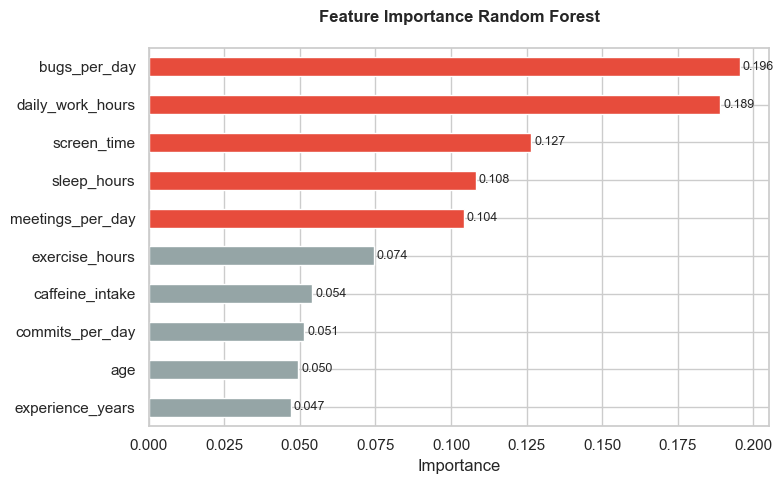


Baseline LR (10 fitur) Test F1 Macro: 0.7855

Top-N    Fitur                                                    Test F1     Drop
----------------------------------------------------------------------------------
Top-10  ['bugs_per_day', 'daily_work_hours', 'screen_time', 'sleep_hours', 'meetings_per_day', 'exercise_hours', 'caffeine_intake', 'commits_per_day', 'age', 'experience_years'] 0.7855   -0.0000kandidat
Top-9   ['bugs_per_day', 'daily_work_hours', 'screen_time', 'sleep_hours', 'meetings_per_day', 'exercise_hours', 'caffeine_intake', 'commits_per_day', 'age'] 0.7871   -0.0016kandidat
Top-8   ['bugs_per_day', 'daily_work_hours', 'screen_time', 'sleep_hours', 'meetings_per_day', 'exercise_hours', 'caffeine_intake', 'commits_per_day'] 0.7841   +0.0014kandidat
Top-7   ['bugs_per_day', 'daily_work_hours', 'screen_time', 'sleep_hours', 'meetings_per_day', 'exercise_hours', 'caffeine_intake'] 0.7850   +0.0005kandidat
Top-6   ['bugs_per_day', 'daily_work_hours', 'screen_time', 'sleep_h

c:\Users\LENOVO\anaconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: F

In [13]:
# --- Feature Importance dari Random Forest ---
rf_best = results['Random Forest']['estimator']
importances = pd.Series(
    rf_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v >= importances.quantile(0.5) else '#95a5a6'
          for v in importances]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance Random Forest\n', fontweight='bold')
ax.set_xlabel('Importance')
for bar, val in zip(ax.patches, importances):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# --- Uji top-N fitur dengan LR (model terbaik) ---
lr_best   = results['Logistic Regression']['estimator']
base_f1   = results['Logistic Regression']['Test F1 Macro']
ranked    = importances.sort_values(ascending=False).index.tolist()

print(f"\nBaseline LR (10 fitur) Test F1 Macro: {base_f1:.4f}\n")
print(f"{'Top-N':<8} {'Fitur':<55} {'Test F1':>8} {'Drop':>8}")
print("-" * 82)

top_n_results = {}
for n in range(len(ranked), 3, -1):
    top_feats = ranked[:n]
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000, random_state=42,
            multi_class='multinomial', solver='lbfgs',
            **{k.replace('model__', ''): v
               for k, v in results['Logistic Regression']['Best Params'].items()}
        ))
    ])
    pipe.fit(X_train[top_feats], y_train)
    f1 = f1_score(y_test, pipe.predict(X_test[top_feats]), average='macro')
    drop = base_f1 - f1
    flag = 'kandidat' if drop < 0.02 else ''
    print(f"Top-{n:<3} {str(top_feats):<55} {f1:.4f}   {drop:+.4f}{flag}")
    top_n_results[n] = {'features': top_feats, 'f1': f1, 'drop': drop}
